# WELFake Dataset – Exploratory Data Analysis & Data Preparation

**Dataset:** `WELFake_Dataset.csv`
**Task:** Supervised Text Classification – Fake News Detection
**Target variable:** `label` (0 = Fake, 1 = Real)

This notebook covers:
1. Exploratory Data Analysis (EDA)
2. Data Preparation (class balancing, cleaning, tokenisation, stopword removal, punctuation removal, train-test split)


## 0. Import Libraries

We import the standard data-handling and visualisation libraries (`pandas`, `numpy`, `matplotlib`, `seaborn`), along with `nltk` for text pre-processing (tokenisation, stopword removal). NLTK resources (`punkt` tokenizer and `stopwords` corpus) are downloaded once at the start.

In [40]:
import pandas as pd
import numpy as np
import re
import string
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

from sklearn.model_selection import train_test_split

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)
RANDOM_STATE = 42

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\junyo\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\junyo\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\junyo\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## 1. Load the Dataset

The dataset is loaded from the CSV file. The first unnamed column is a leftover row index from the original export, so it is dropped.

In [41]:
df = pd.read_csv('WELFake_Dataset.csv')

# Drop the leftover index column exported with the CSV
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

df.head()

,title,text,label
0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1
1,NaN,Did they post their votes for Hillary already?,1
2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1
3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0
4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1


## 2. Exploratory Data Analysis (EDA)

### 2.1 Dataset Dimensions

We first check the size of the dataset (number of rows/articles and number of columns/features) and the data types of each column.

In [42]:
print(f"Dataset shape: {df.shape[0]} rows, {df.shape[1]} columns")
print()
print("Column data types:")
print(df.dtypes)
print()
df.info()

Dataset shape: 72134 rows, 3 columns

Column data types:
title      str
text       str
label    int64
dtype: object

<class 'pandas.DataFrame'>
RangeIndex: 72134 entries, 0 to 72133
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   title   71576 non-null  str  
 1   text    72095 non-null  str  
 2   label   72134 non-null  int64
dtypes: int64(1), str(2)
memory usage: 1.7 MB


### 2.2 Missing Values

We check each column for missing (null) values. News articles are often scraped from the web, so it is common for the `title` or `text` fields to be missing for a small number of records.

       Missing Count  Missing %
title            558       0.77
text              39       0.05
label              0       0.00


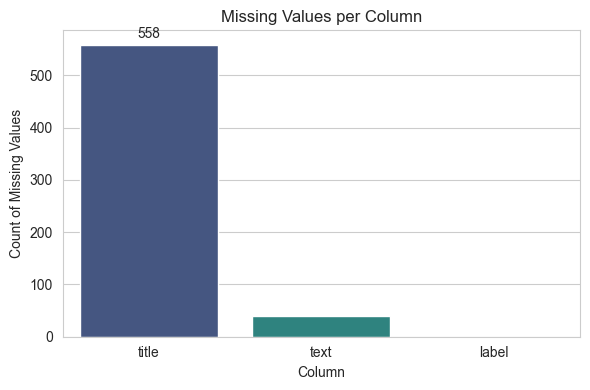

In [43]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_summary = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_summary)

# Visualise missing values
plt.figure(figsize=(6, 4))
ax = sns.barplot(x=missing_summary.index, y=missing_summary['Missing Count'], hue=missing_summary.index, palette='viridis', legend=False)
plt.title('Missing Values per Column')
plt.ylabel('Count of Missing Values')
plt.xlabel('Column')
ax.bar_label(ax.containers[0], fmt='%d', padding=3)
plt.tight_layout()
plt.show()

Rows with a missing `text` field are not usable for classification (there is no article body to analyse), so these will be removed. A missing `title` is less critical since `text` is the primary field used for classification, but we handle it during cleaning.

In [44]:
# Drop rows where the article text itself is missing
df = df.dropna(subset=['text']).reset_index(drop=True)

# Fill missing titles with an empty string so they don't break later string operations
df['title'] = df['title'].fillna('')

print(f"Shape after removing rows with missing text: {df.shape}")

Shape after removing rows with missing text: (72095, 3)


### 2.3 Duplicates

Duplicate articles can bias the model (e.g. by over-representing certain patterns) and can also leak between the train and test sets if not removed first. We check for fully duplicated rows and for duplicated `text` values (the same article body appearing more than once, even if the title differs slightly).

In [45]:
full_duplicates = df.duplicated().sum()
text_duplicates = df.duplicated(subset=['text']).sum()

print(f"Fully duplicated rows: {full_duplicates}")
print(f"Rows with duplicated 'text' field: {text_duplicates}")

# Remove duplicate articles (keep the first occurrence), based on the text field
df = df.drop_duplicates(subset=['text']).reset_index(drop=True)

print(f"Shape after removing duplicates: {df.shape}")

Fully duplicated rows: 8456
Rows with duplicated 'text' field: 9377
Shape after removing duplicates: (62718, 3)


### 2.4 Class Distribution

We examine how many articles fall into each class (0 = Fake, 1 = Real) to check whether the dataset is balanced. A heavily imbalanced dataset would require techniques such as class weighting, oversampling, or undersampling before model training.

Class distribution:
  Fake (0): 34620 articles (55.2%)
  Real (1): 28098 articles (44.8%)


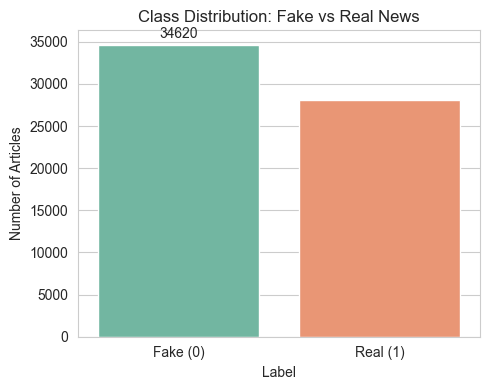

In [46]:
class_counts = df['label'].value_counts().sort_index()
class_pct = (class_counts / len(df) * 100).round(2)

print("Class distribution:")
for label, count in class_counts.items():
    name = 'Fake (0)' if label == 0 else 'Real (1)'
    print(f"  {name}: {count} articles ({class_pct[label]}%)")

plt.figure(figsize=(5, 4))
ax = sns.countplot(x='label', data=df, hue='label', palette='Set2', legend=False)
ax.set_xticks([0, 1])
ax.set_xticklabels(['Fake (0)', 'Real (1)'])
plt.title('Class Distribution: Fake vs Real News')
plt.xlabel('Label')
plt.ylabel('Number of Articles')
ax.bar_label(ax.containers[0], fmt='%d', padding=3)
plt.tight_layout()
plt.show()

The dataset shows a **mild class imbalance** (roughly 55% Fake vs 45% Real). This is not severe enough to bias a model on its own, but to remove any doubt and give every model an equal number of examples per class to learn from, **undersampling is applied in the Data Preparation stage below** to bring the classes to an exact 50/50 split.

### 2.5 Text Length Analysis

We compute the length of each article (in characters and in word count) to understand the typical size of the documents, and compare this across the two classes. Extremely short or long articles can also indicate noisy/low-quality records worth inspecting.

In [47]:
df['char_length'] = df['text'].apply(len)
df['word_count'] = df['text'].apply(lambda x: len(x.split()))

print("Character length statistics:")
print(df['char_length'].describe())
print()
print("Word count statistics:")
print(df['word_count'].describe())

Character length statistics:
count     62718.000000
mean       3316.446746
std        3631.818948
min           1.000000
25%        1477.000000
50%        2480.000000
75%        4131.750000
max      142961.000000
Name: char_length, dtype: float64

Word count statistics:
count    62718.000000
mean       548.983641
std        610.055911
min          0.000000
25%        244.000000
50%        406.000000
75%        679.000000
max      24234.000000
Name: word_count, dtype: float64


Mean word count -> Fake: 580.9 | Real: 509.6


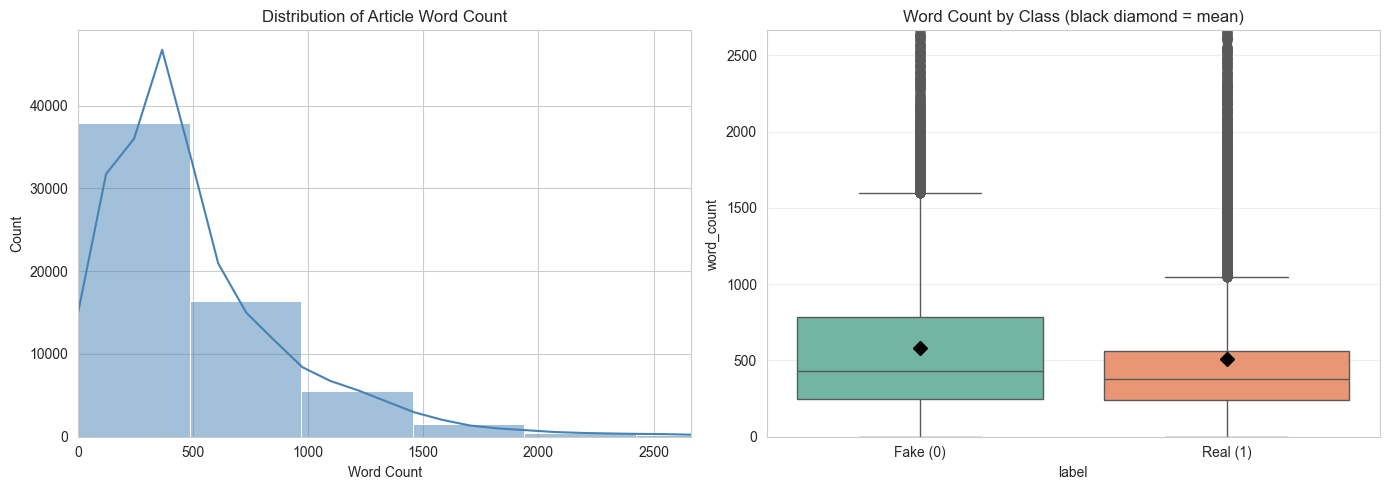

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['word_count'], bins=50, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Distribution of Article Word Count')
axes[0].set_xlabel('Word Count')
axes[0].set_xlim(0, df['word_count'].quantile(0.99))  # trim extreme outliers for readability

sns.boxplot(x='label', y='word_count', data=df, hue='label', palette='Set2', legend=False, ax=axes[1],
            showmeans=True,
            meanprops={'marker': 'D', 'markerfacecolor': 'black', 'markeredgecolor': 'black', 'markersize': 7})
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['Fake (0)', 'Real (1)'])
axes[1].set_title('Word Count by Class (black diamond = mean)')
axes[1].set_ylim(0, df['word_count'].quantile(0.99))
axes[1].grid(axis='y', alpha=0.3)

mean_fake = df.loc[df['label'] == 0, 'word_count'].mean()
mean_real = df.loc[df['label'] == 1, 'word_count'].mean()
print(f"Mean word count -> Fake: {mean_fake:.1f} | Real: {mean_real:.1f}")

plt.tight_layout()
plt.show()


### 2.6 Additional Visualisations

**Word clouds** give a quick qualitative view of the most frequent words in each class, which can hint at vocabulary differences between fake and real news before any modelling is done.

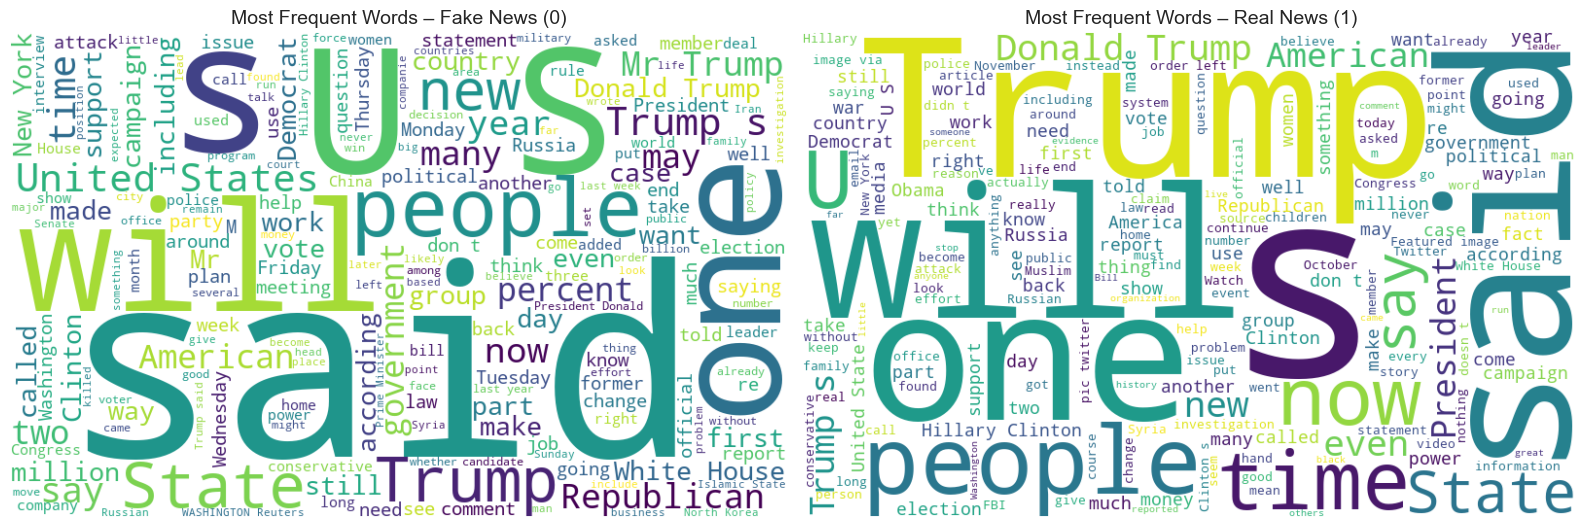

In [49]:
# Install wordcloud if not already available
try:
    from wordcloud import WordCloud
except ImportError:
    import sys, subprocess
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'wordcloud', '--quiet'])
    from wordcloud import WordCloud

fake_text = ' '.join(df[df['label'] == 0]['text'].sample(min(2000, len(df[df['label']==0])), random_state=42))
real_text = ' '.join(df[df['label'] == 1]['text'].sample(min(2000, len(df[df['label']==1])), random_state=42))

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

wc_fake = WordCloud(width=800, height=500, background_color='white', stopwords=None).generate(fake_text)
axes[0].imshow(wc_fake, interpolation='bilinear')
axes[0].set_title('Most Frequent Words – Fake News (0)', fontsize=14)
axes[0].axis('off')

wc_real = WordCloud(width=800, height=500, background_color='white', stopwords=None).generate(real_text)
axes[1].imshow(wc_real, interpolation='bilinear')
axes[1].set_title('Most Frequent Words – Real News (1)', fontsize=14)
axes[1].axis('off')

plt.tight_layout()
plt.show()

A correlation heatmap of the numeric features derived so far (`char_length`, `word_count`) against the `label` gives a quick check on whether article length alone carries any predictive signal.

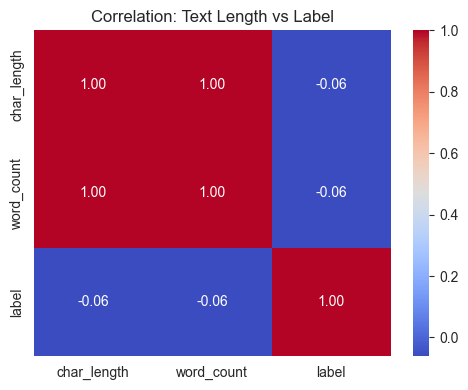

In [50]:
plt.figure(figsize=(5, 4))
corr = df[['char_length', 'word_count', 'label']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation: Text Length vs Label')
plt.tight_layout()
plt.show()

## 3. Data Preparation

Before feeding the text into any classification model, the raw article text needs to be balanced and normalised. This section explains and demonstrates each step: **class balancing (undersampling)**, **cleaning**, **tokenisation**, **stopword removal**, **punctuation removal**, and finally the **train-test split**.

### 3.1 Class Balancing (Undersampling)

The EDA above showed a mild class imbalance (~55% Fake vs ~45% Real). Rather than relying only on `class_weight='balanced'` inside individual models, we apply **random undersampling** here: the majority class (Fake) is randomly downsampled, *without replacement*, to match the number of articles in the minority class (Real). This gives every model an exactly balanced 50/50 training signal and simplifies interpretation of accuracy alongside the other metrics.

This is done **before** cleaning/tokenisation so that all downstream pre-processing and modelling steps operate on the already-balanced dataset.

In [51]:
counts_before = df['label'].value_counts()

print("Class distribution BEFORE undersampling:")
print(counts_before)

if counts_before.nunique() == 1:
    print("\nClasses are already balanced — skipping undersampling.")
    counts_after = counts_before

else:
    majority_label = counts_before.idxmax()
    minority_label = counts_before.idxmin()

    majority_size = counts_before[majority_label]
    minority_size = counts_before[minority_label]

    # Target approximately 52:48 majority-to-minority ratio
    target_ratio = 52 / 48

    target_majority_size = int(minority_size * target_ratio)

    print(f"\nMajority class: {majority_label}")
    print(f"Minority class: {minority_label}")
    print(f"Target majority size: {target_majority_size}")

    df_majority = df[df['label'] == majority_label]
    df_minority = df[df['label'] == minority_label]

    # Partial undersampling
    df_majority_downsampled = df_majority.sample(
        n=target_majority_size,
        random_state=RANDOM_STATE
    )

    df = pd.concat([
        df_majority_downsampled,
        df_minority
    ])

    # Shuffle
    df = df.sample(
        frac=1,
        random_state=RANDOM_STATE
    ).reset_index(drop=True)

    counts_after = df['label'].value_counts()

print("\nClass distribution AFTER undersampling:")
print(counts_after)

print(f"\nNew dataset shape: {df.shape}")

Class distribution BEFORE undersampling:
label
0    34620
1    28098
Name: count, dtype: int64

Majority class: 0
Minority class: 1
Target majority size: 30439

Class distribution AFTER undersampling:
label
0    30439
1    28098
Name: count, dtype: int64

New dataset shape: (58537, 5)


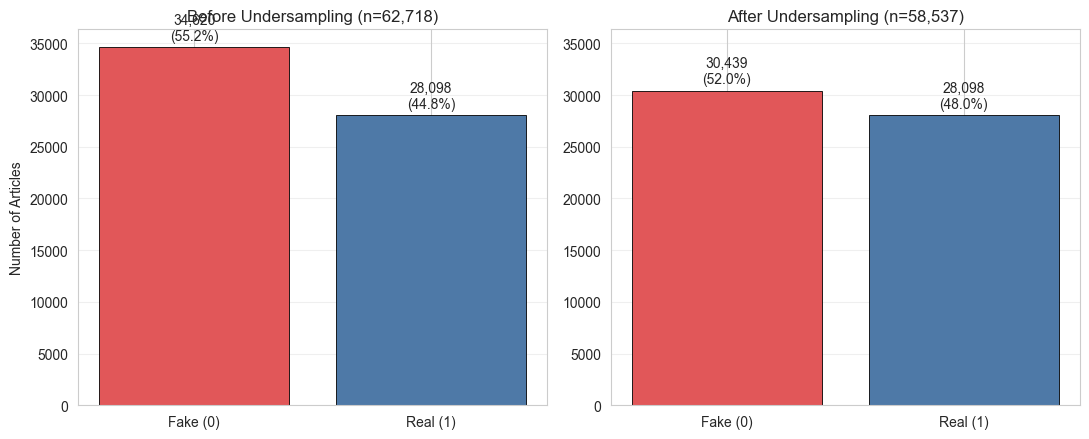

In [52]:
# Visualise the effect of undersampling: before vs after
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# Cast keys to plain Python ints so lookups are safe regardless of the
# original index dtype (int64/object/etc.), and use dicts with .get()
# so a missing label doesn't raise a KeyError.
counts_before_map = {int(k): v for k, v in counts_before.items()}
counts_after_map = {int(k): v for k, v in counts_after.items()}

labels_order = sorted(counts_before_map.keys())
label_names = ['Fake (0)' if l == 0 else 'Real (1)' for l in labels_order]
colors = ['#e15759', '#4e79a7']

total_before = sum(counts_before_map.values())
before_vals = [counts_before_map.get(l, 0) for l in labels_order]
bars0 = axes[0].bar(label_names, before_vals,
                     color=colors, edgecolor='black', linewidth=0.6)
axes[0].set_title(f'Before Undersampling (n={total_before:,})')
axes[0].set_ylabel('Number of Articles')
axes[0].bar_label(
    bars0,
    labels=[f'{v:,}\n({v / total_before:.1%})' for v in before_vals],
    padding=3
)
axes[0].grid(axis='y', alpha=0.3)

total_after = sum(counts_after_map.values())
after_vals = [counts_after_map.get(l, 0) for l in labels_order]
bars1 = axes[1].bar(label_names, after_vals,
                     color=colors, edgecolor='black', linewidth=0.6)
axes[1].set_title(f'After Undersampling (n={total_after:,})')
axes[1].bar_label(
    bars1,
    labels=[f'{v:,}\n({v / total_after:.1%})' for v in after_vals],
    padding=3
)
axes[1].set_ylim(axes[0].get_ylim())  # same y-scale as 'before' for a fair visual comparison
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### 3.2 Combining Title and Text

For classification we combine the `title` and `text` fields into a single `content` field, since the headline often carries useful signal for fake-news detection.

In [53]:
df['content'] = df['title'] + ' ' + df['text']
df[['content', 'label']].head()

,content,label
0,A Brother’s Crimes and a Sister’s Betrayal Mak...,0
1,Chance the Rapper Donates $1 Million to Chicag...,0
2,Is it coming into clearer focus for Americans ...,1
3,Trump administration moves closer to undoing o...,0
4,Trump gives CIA authority to conduct drone str...,0


### 3.3 Cleaning

Raw web-scraped text typically contains noise that does not carry meaningful information for classification, such as:
- URLs and HTML artifacts
- Non-alphabetic characters (numbers, special symbols)
- Inconsistent casing (e.g. "News" vs "news" being treated as different tokens)
- Extra whitespace

We define a `clean_text` function that lowercases the text, strips URLs, removes non-alphabetic characters, and collapses whitespace. This standardises the text so that the same word is always represented the same way, which is essential before tokenisation and vectorisation.

In [54]:
def clean_text(text):
    text = text.lower()                                  # normalise case
    text = re.sub(r'http\S+|www\S+', ' ', text)          # remove URLs
    text = re.sub(r'<.*?>', ' ', text)                    # remove HTML tags
    text = re.sub(r'[^a-z\s]', ' ', text)                 # keep only letters
    text = re.sub(r'\s+', ' ', text).strip()              # collapse whitespace
    return text

df['clean_content'] = df['content'].apply(clean_text)

print("Before cleaning:\n", df['content'].iloc[0][:300])
print("\nAfter cleaning:\n", df['clean_content'].iloc[0][:300])

Before cleaning:
 A Brother’s Crimes and a Sister’s Betrayal Make ‘Judas’ a Dutch Best Seller - The New York Times AMSTERDAM  —   When he read the   sample of Astrid Holleeder’s memoir, “Judas,” in the spring, the Dutch publisher Oscar van Gelderen said he knew he had sensational material in his hands. A gangster bos

After cleaning:
 a brother s crimes and a sister s betrayal make judas a dutch best seller the new york times amsterdam when he read the sample of astrid holleeder s memoir judas in the spring the dutch publisher oscar van gelderen said he knew he had sensational material in his hands a gangster boss who has become 


### 3.4 Tokenisation

Tokenisation splits the cleaned text into individual word units (tokens), which is the standard input format expected by NLTK and Sklearn text-processing pipelines. We use NLTK's `word_tokenize`, consistent with the approach demonstrated in the labs.

In [55]:
df['tokens'] = df['clean_content'].apply(word_tokenize)

print("Example tokens (first 20):")
print(df['tokens'].iloc[0][:20])

Example tokens (first 20):
['a', 'brother', 's', 'crimes', 'and', 'a', 'sister', 's', 'betrayal', 'make', 'judas', 'a', 'dutch', 'best', 'seller', 'the', 'new', 'york', 'times', 'amsterdam']


### 3.5 Punctuation Removal

Although most punctuation is already removed by the regular expression used during cleaning (since we kept only alphabetic characters), this step is shown explicitly using Python's `string.punctuation` set, in line with standard NLTK pre-processing practice. This guards against any punctuation-attached tokens that may slip through (e.g. from apostrophes or hyphens if the cleaning regex is relaxed).

In [56]:
punctuations = set(string.punctuation)

def remove_punctuation(tokens):
    return [t for t in tokens if t not in punctuations]

df['tokens'] = df['tokens'].apply(remove_punctuation)

print("Punctuation characters checked against:")
print(punctuations)

Punctuation characters checked against:
{']', '-', '|', '*', '`', "'", '/', '\\', '$', '=', '@', '.', '?', '!', '<', '+', '&', '#', '^', '{', '>', '"', '~', '}', '%', '[', '(', '_', ';', ':', ')', ','}


### 3.6 Stopword Removal

Stopwords (e.g. *the, is, at, which, on*) are high-frequency words that carry little discriminative meaning for classification tasks. Removing them reduces noise and dimensionality, letting the model focus on words that actually help distinguish fake from real news. We use NLTK's built-in English stopword list.

In [57]:
stop_words = set(stopwords.words('english'))
print(f"Number of English stopwords: {len(stop_words)}")
print(f"Example stopwords: {list(stop_words)[:15]}")

def remove_stopwords(tokens):
    return [t for t in tokens if t not in stop_words and len(t) > 1]

df['tokens'] = df['tokens'].apply(remove_stopwords)

print("\nExample tokens after stopword removal:")
print(df['tokens'].iloc[0][:20])

Number of English stopwords: 198
Example stopwords: ['hers', 'herself', "it's", 'myself', "she'd", 'then', 'or', "wasn't", "i'm", 'she', 'if', 'that', "mustn't", "couldn't", "shan't"]

Example tokens after stopword removal:
['brother', 'crimes', 'sister', 'betrayal', 'make', 'judas', 'dutch', 'best', 'seller', 'new', 'york', 'times', 'amsterdam', 'read', 'sample', 'astrid', 'holleeder', 'memoir', 'judas', 'spring']


Finally, we join the processed tokens back into a single string per document. This `final_text` column is the fully cleaned, balanced, tokenised, and normalised representation that will be passed into the vectorisation step (e.g. TF-IDF / Bag-of-Words) for model training.

In [58]:
df['final_text'] = df['tokens'].apply(lambda tokens: ' '.join(tokens))

df[['content', 'final_text', 'label']].head()

,content,final_text,label
0,A Brother’s Crimes and a Sister’s Betrayal Mak...,brother crimes sister betrayal make judas dutc...,0
1,Chance the Rapper Donates $1 Million to Chicag...,chance rapper donates million chicago public s...,0
2,Is it coming into clearer focus for Americans ...,coming clearer focus americans gilad atzmon oc...,1
3,Trump administration moves closer to undoing o...,trump administration moves closer undoing over...,0
4,Trump gives CIA authority to conduct drone str...,trump gives cia authority conduct drone strike...,0


### 3.7 Train-Test Split

We split the pre-processed, class-balanced data into a training set and a testing set. The model will learn only from the training set, and its performance will be evaluated on the unseen testing set. We use an 80/20 split, and `stratify=df['label']` to preserve the same (now 50/50) class balance in both sets. A fixed `random_state` ensures the split is reproducible.

In [59]:
X = df['final_text']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f"Training set size: {X_train.shape[0]} articles")
print(f"Testing set size:  {X_test.shape[0]} articles")
print()
print("Training set class distribution:")
print(y_train.value_counts(normalize=True).round(3))
print()
print("Testing set class distribution:")
print(y_test.value_counts(normalize=True).round(3))

Training set size: 46829 articles
Testing set size:  11708 articles

Training set class distribution:
label
0    0.52
1    0.48
Name: proportion, dtype: float64

Testing set class distribution:
label
0    0.52
1    0.48
Name: proportion, dtype: float64


The training and testing sets are now ready — both drawn from the class-balanced dataset. `X_train`/`y_train` will be used to fit the classification models, and `X_test`/`y_test` will be held out purely for evaluation in the next stage of the assignment (vectorisation, model building, hyperparameter tuning, and evaluation).

## 4. Save Processed Data for the Next Notebook

To keep this pipeline connected to the **Supervised Text Classification** notebook without re-running or duplicating the cleaning steps, we save the fully preprocessed, class-balanced dataset (`final_text` and `label`) to a CSV file. The classification notebook will load this file directly and perform the same `train_test_split` (using the same `random_state`) to reproduce identical training/testing sets.

In [60]:
df[['final_text', 'label']].to_csv('WELFake_processed.csv', index=False)

print(f"Saved {df.shape[0]} preprocessed, class-balanced articles to 'WELFake_processed.csv'")
print("Columns saved: ['final_text', 'label']")
pd.read_csv('WELFake_processed.csv').head()

Saved 58537 preprocessed, class-balanced articles to 'WELFake_processed.csv'
Columns saved: ['final_text', 'label']


,final_text,label
0,brother crimes sister betrayal make judas dutc...,0
1,chance rapper donates million chicago public s...,0
2,coming clearer focus americans gilad atzmon oc...,1
3,trump administration moves closer undoing over...,0
4,trump gives cia authority conduct drone strike...,0
